# Visualizing `batch_15_notices.json` in a pandas DataFrame

This notebook loads the synthetic notices JSON file into a pandas DataFrame and shows a few basic summaries and visualizations for quick inspection.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
# Load JSON file into a pandas DataFrame
base_dir = Path.cwd()
print(base_dir)
json_path = base_dir / "output" / "LLM_generated" / "batch_15_notices.json"

with json_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

# `notices` is the list we care about for tabular analysis
notices = data["notices"]

# Create a DataFrame
notices_df = pd.DataFrame(notices)

notices_df.head()

c:\Users\Andres.DESKTOP-D77KM25\OneDrive - Stanford\2021 - 2025\2025-2026\AI for Legal Help\repo\law809e\synthetic_notices


,text,defects,is_valid,metadata
0,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None
1,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None
2,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None
3,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None
4,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None


In [4]:
# Create one-hot defect indicator columns (1 = present, 0 = absent)

# Get the set of all unique defect codes across the dataset
all_defects = sorted({d for row in notices_df["defects"] for d in row})

for defect in all_defects:
    col_name = f"defect__{defect}"
    notices_df[col_name] = notices_df["defects"].apply(lambda ds: int(defect in ds))

# Inspect the updated DataFrame with defect indicator columns
notices_df.head()

,text,defects,is_valid,metadata,defect__financial_institution_incomplete,defect__insufficient_period,defect__missing_payee_info,defect__missing_payment_hours,defect__no_amount_stated,defect__no_forfeiture,defect__not_disjunctive,defect__rent_over_one_year
0,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
1,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
2,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
3,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
4,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0


In [5]:
notices_df

,text,defects,is_valid,metadata,defect__financial_institution_incomplete,defect__insufficient_period,defect__missing_payee_info,defect__missing_payment_hours,defect__no_amount_stated,defect__no_forfeiture,defect__not_disjunctive,defect__rent_over_one_year
0,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
1,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
2,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
3,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
4,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
5,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
6,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
7,3-DAY NOTICE TO PAY RENT AND QUIT\n\nDate: Oct...,"[no_amount_stated, not_disjunctive]",False,None,0,0,0,0,1,0,1,0
8,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[insufficient_period],False,None,0,1,0,0,0,0,0,0
9,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,"[no_forfeiture, missing_payee_info]",False,None,0,0,1,0,0,1,0,0


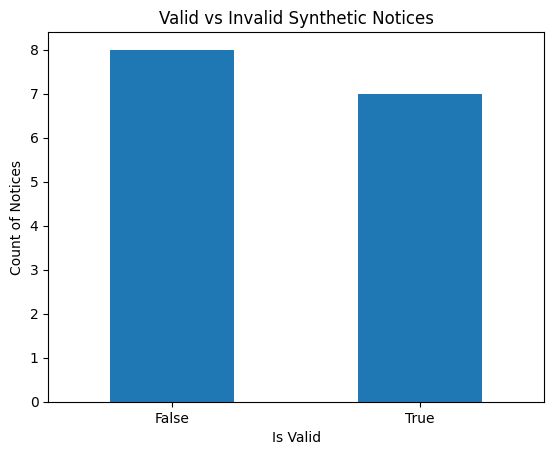

is_valid
False    8
True     7
Name: count, dtype: int64

In [6]:
# Basic validity breakdown
valid_counts = notices_df["is_valid"].value_counts().sort_index()

ax = valid_counts.plot(kind="bar", rot=0)
ax.set_xlabel("Is Valid")
ax.set_ylabel("Count of Notices")
ax.set_title("Valid vs Invalid Synthetic Notices")
plt.show()

valid_counts

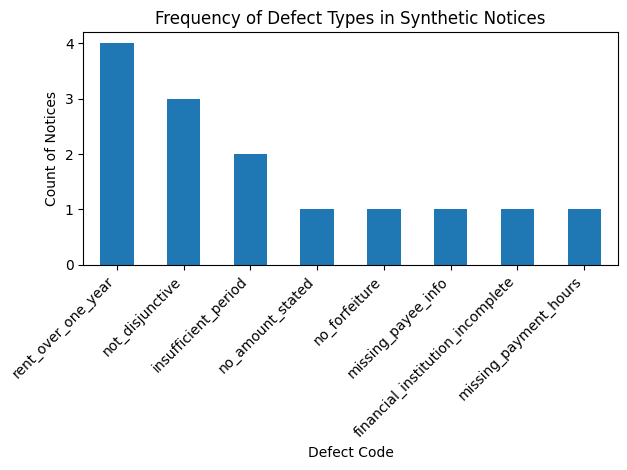

defects
rent_over_one_year                  4
not_disjunctive                     3
insufficient_period                 2
no_amount_stated                    1
no_forfeiture                       1
missing_payee_info                  1
financial_institution_incomplete    1
missing_payment_hours               1
Name: count, dtype: int64

In [7]:
# Frequency of each defect type (for invalid notices)
# `defects` is a list column; we "explode" it so each defect gets its own row

defects_exploded = notices_df.explode("defects")

# Filter out rows where `defects` is null (i.e., valid notices)
non_null_defects = defects_exploded[defects_exploded["defects"].notna()]

defect_counts = non_null_defects["defects"].value_counts()

ax = defect_counts.plot(kind="bar")
ax.set_xlabel("Defect Code")
ax.set_ylabel("Count of Notices")
ax.set_title("Frequency of Defect Types in Synthetic Notices")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

defect_counts

In [8]:
import os
print(os.getcwd())
notices_df.to_csv("batch_30_notices.csv", index=False)

c:\Users\Andres.DESKTOP-D77KM25\OneDrive - Stanford\2021 - 2025\2025-2026\AI for Legal Help\repo\law809e\synthetic_notices


## Evaluation Results — eval_batch15_llm_google_v2

Precision / Recall / F1 and raw TP/FP/FN counts for the checker pipeline run against `batch_15_notices.json` using **Google** as the LLM provider.

In [9]:
import json
from pathlib import Path

eval_path = Path.cwd().parent / "eval_batch15_llm_google_v2.json"
with eval_path.open("r", encoding="utf-8") as f:
    eval_data = json.load(f)

summary = eval_data["summary"]
per_defect = eval_data["per_defect"]

defect_ids = list(per_defect.keys())  # MVP-001 … MVP-009
exact_match_pct = summary["exact_match_pct"]

DEFECT_NAMES = {
    "MVP-001": "Missing 'pay OR quit'\nphrasing",
    "MVP-002": "Insufficient\nnotice period",
    "MVP-003": "No exact\ndollar amount",
    "MVP-004": "Missing\npayee info",
    "MVP-005": "Missing\npayment hours",
    "MVP-006": "Missing financial\ninstitution info",
    "MVP-007": "Electronic payment\nnot established",
    "MVP-008": "Rent over\none year old",
    "MVP-009": "No forfeiture\ndeclaration",
}

defect_labels = [DEFECT_NAMES[d] for d in defect_ids]

print(f"Total notices: {summary['total']}")
print(f"Exact-match accuracy: {exact_match_pct}%")

Total notices: 15
Exact-match accuracy: 73.3%


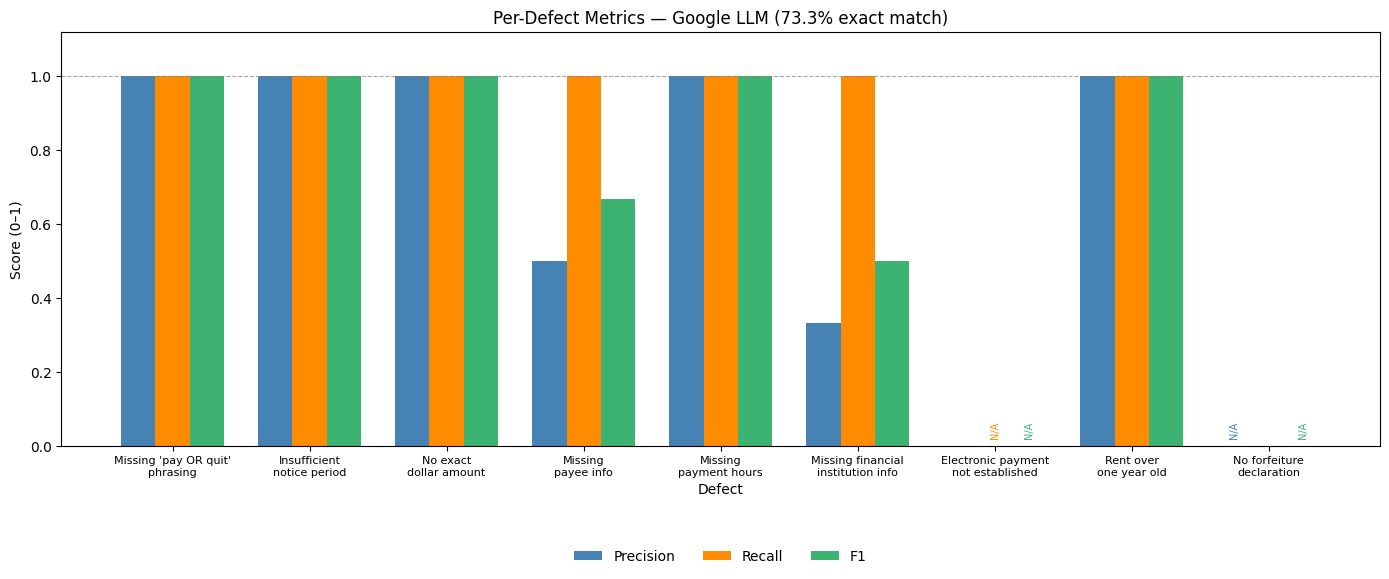

In [10]:
import numpy as np

# --- Chart 1: Per-Defect Precision / Recall / F1 (grouped bar chart) ---

precision = [per_defect[d]["precision"] or 0.0 for d in defect_ids]
recall    = [per_defect[d]["recall"]    or 0.0 for d in defect_ids]
f1        = [per_defect[d]["f1"]        or 0.0 for d in defect_ids]

# Track which values were originally null (for annotation)
null_precision = [d for d in defect_ids if per_defect[d]["precision"] is None]
null_f1        = [d for d in defect_ids if per_defect[d]["f1"] is None]
null_recall    = [d for d in defect_ids if per_defect[d]["recall"] is None]

x = np.arange(len(defect_ids))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width, precision, width, label="Precision", color="steelblue")
ax.bar(x,         recall,    width, label="Recall",    color="darkorange")
ax.bar(x + width, f1,        width, label="F1",        color="mediumseagreen")

# Reference line at y=1.0
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)

# Annotate null values with "N/A" above the (zero-height) bar
for i, d in enumerate(defect_ids):
    if d in null_precision:
        ax.text(x[i] - width, 0.02, "N/A", ha="center", va="bottom", fontsize=7, color="steelblue", rotation=90)
    if d in null_recall:
        ax.text(x[i], 0.02, "N/A", ha="center", va="bottom", fontsize=7, color="darkorange", rotation=90)
    if d in null_f1:
        ax.text(x[i] + width, 0.02, "N/A", ha="center", va="bottom", fontsize=7, color="mediumseagreen", rotation=90)

ax.set_xlabel("Defect")
ax.set_ylabel("Score (0–1)")
ax.set_title(f"Per-Defect Metrics — Google LLM ({exact_match_pct}% exact match)")
ax.set_xticks(x)
ax.set_xticklabels(defect_labels, rotation=0, ha="center", fontsize=8)
ax.set_ylim(0, 1.12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

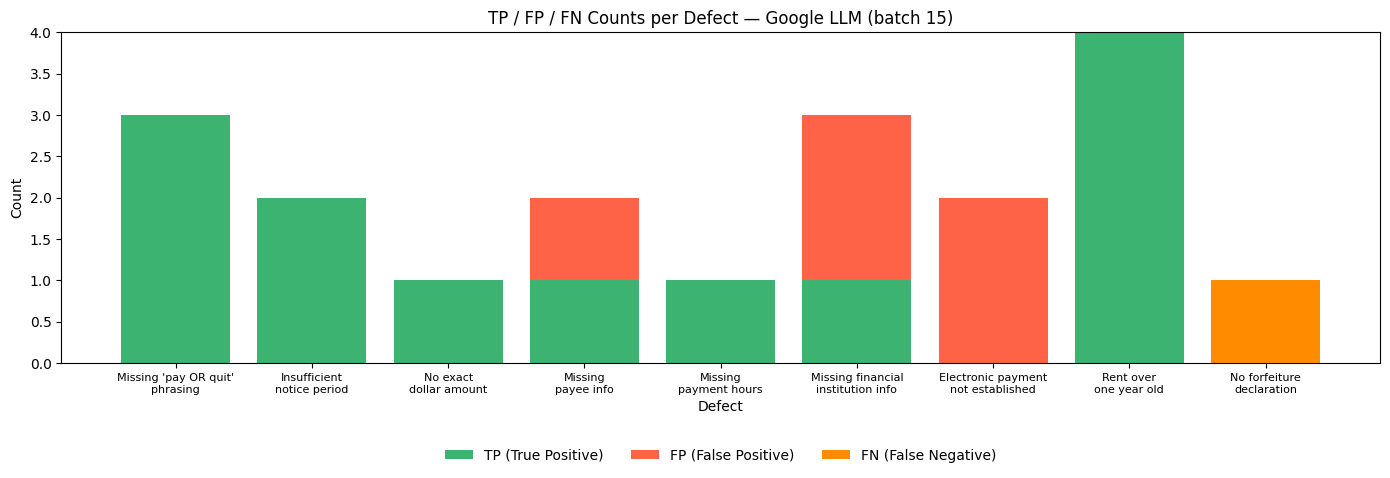

In [11]:
# --- Chart 2: TP / FP / FN Counts per Defect (stacked bar chart) ---

tp_vals = [per_defect[d]["tp"] for d in defect_ids]
fp_vals = [per_defect[d]["fp"] for d in defect_ids]
fn_vals = [per_defect[d]["fn"] for d in defect_ids]

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(defect_labels, tp_vals, label="TP (True Positive)",  color="mediumseagreen")
ax.bar(defect_labels, fp_vals, label="FP (False Positive)", color="tomato",        bottom=tp_vals)
ax.bar(defect_labels, fn_vals, label="FN (False Negative)", color="darkorange",
       bottom=[tp + fp for tp, fp in zip(tp_vals, fp_vals)])

ax.set_xlabel("Defect")
ax.set_ylabel("Count")
ax.set_title("TP / FP / FN Counts per Defect — Google LLM (batch 15)")
ax.tick_params(axis="x", labelsize=8)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

## Evaluation Results — eval_batch15_regex (Rule-Based / Regex)

Precision / Recall / F1 and raw TP/FP/FN counts for the checker pipeline run against `batch_15_notices.json` using the **rule-based / regex** extractor (no LLM API calls).

In [ ]:
eval_path_regex = Path.cwd().parent / "eval_batch15_regex.json"
with eval_path_regex.open("r", encoding="utf-8") as f:
    eval_data_regex = json.load(f)

summary_regex = eval_data_regex["summary"]
per_defect_regex = eval_data_regex["per_defect"]
exact_match_pct_regex = summary_regex["exact_match_pct"]

print(f"Total notices: {summary_regex['total']}")
print(f"Exact-match accuracy: {exact_match_pct_regex}%")

In [ ]:
# --- Chart 1: Per-Defect Precision / Recall / F1 (grouped bar chart) ---

precision_r = [per_defect_regex[d]["precision"] or 0.0 for d in defect_ids]
recall_r    = [per_defect_regex[d]["recall"]    or 0.0 for d in defect_ids]
f1_r        = [per_defect_regex[d]["f1"]        or 0.0 for d in defect_ids]

null_precision_r = [d for d in defect_ids if per_defect_regex[d]["precision"] is None]
null_recall_r    = [d for d in defect_ids if per_defect_regex[d]["recall"] is None]
null_f1_r        = [d for d in defect_ids if per_defect_regex[d]["f1"] is None]

x = np.arange(len(defect_ids))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width, precision_r, width, label="Precision", color="steelblue")
ax.bar(x,         recall_r,    width, label="Recall",    color="darkorange")
ax.bar(x + width, f1_r,        width, label="F1",        color="mediumseagreen")

ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)

for i, d in enumerate(defect_ids):
    if d in null_precision_r:
        ax.text(x[i] - width, 0.02, "N/A", ha="center", va="bottom", fontsize=7, color="steelblue", rotation=90)
    if d in null_recall_r:
        ax.text(x[i], 0.02, "N/A", ha="center", va="bottom", fontsize=7, color="darkorange", rotation=90)
    if d in null_f1_r:
        ax.text(x[i] + width, 0.02, "N/A", ha="center", va="bottom", fontsize=7, color="mediumseagreen", rotation=90)

ax.set_xlabel("Defect")
ax.set_ylabel("Score (0–1)")
ax.set_title(f"Per-Defect Metrics — Rule-Based / Regex ({exact_match_pct_regex}% exact match)")
ax.set_xticks(x)
ax.set_xticklabels(defect_labels, rotation=0, ha="center", fontsize=8)
ax.set_ylim(0, 1.12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# --- Chart 2: TP / FP / FN Counts per Defect (stacked bar chart) ---

tp_r = [per_defect_regex[d]["tp"] for d in defect_ids]
fp_r = [per_defect_regex[d]["fp"] for d in defect_ids]
fn_r = [per_defect_regex[d]["fn"] for d in defect_ids]

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(defect_labels, tp_r, label="TP (True Positive)",  color="mediumseagreen")
ax.bar(defect_labels, fp_r, label="FP (False Positive)", color="tomato",        bottom=tp_r)
ax.bar(defect_labels, fn_r, label="FN (False Negative)", color="darkorange",
       bottom=[tp + fp for tp, fp in zip(tp_r, fp_r)])

ax.set_xlabel("Defect")
ax.set_ylabel("Count")
ax.set_title("TP / FP / FN Counts per Defect — Rule-Based / Regex (batch 15)")
ax.tick_params(axis="x", labelsize=8)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False)

plt.tight_layout()
plt.show()